## Proyecto 02- Clasificación Datos BCI

Pamula Huacca Arce | Paula Andrea C. Cano

## **1. Seleccción de índices**

- **Índice 1:** Sincronización Funcional mediante el Valor de Bloqueo de Fase (PLV - Dominio de la Fase)

El Valor de Bloqueo de Fase (Phase Locking Value - PLV) es una métrica no lineal y una medida de conectividad funcional que cuantifica el grado de sincronización en fase entre dos señales de electroencefalograma (EEG) registradas en diferentes puntos del cuero cabelludo, de manera independiente a las variaciones en sus amplitudes o voltajes. El PLV se calcula matemáticamente evaluando la constancia de la diferencia de fase entre un par de electrodos (como la pareja contralateral C3-C4) a lo largo del tiempo dentro de una banda de frecuencia específica (Mu o Beta), acotando sus valores estrictamente en un rango de 0 (ausencia total de sincronización o fases aleatorias) a 1 (sincronización de fase perfecta y constante) [1,2].

En esta segunda parte del proyecto, enfocada en diferenciar los estados de reposo de la imaginación motora de la mano derecha e izquierda en los 109 sujetos, el PLV aporta una dimensión informativa crucial que complementa los análisis tradicionales. Durante el estado de reposo, las áreas motoras de ambos hemisferios suelen mantener una comunicación basal acoplada y rítmica. Sin embargo, al activar la imaginación motora, el fenómeno de desincronización relacionada con eventos (ERD) interrumpe drásticamente este acoplamiento interhemisférico de forma lateralizada; las poblaciones neuronales del hemisferio contralateral al miembro imaginado empiezan a disparar de forma independiente, alterando la estabilidad de la fase con respecto al hemisferio ipsilateral. Investigaciones neurofisiológicas han demostrado que incluir el acoplamiento de fase a través del PLV mitiga el impacto de las diferencias físicas e impedancias inter-sujeto, proveyendo al modelo de Machine Learning y a las Redes Neuronales descriptores de red estables que discriminan con alta precisión los cambios dinámicos de la conectividad funcional en tareas BCI [3].


- **Índice 2:** Entropía Shannon - Medida dinámica no lineal

La entropía de la información (Entropía de Shannon para este proyecto) es una métrica de la teoría de la información que cuantifica la complejidad, el grado de incertidumbre o el caos de una serie temporal. A diferencia de las métricas tradicionales que asumen linealidad en la señal, la entropía evalúa el comportamiento dinámico no lineal del electroencefalograma (EEG). Un valor de entropía bajo indica que la señal es altamente rítmica, predecible y ordenada, mientras que un valor de entropía alto refleja un patrón más desordenado y complejo con mayor contenido de información [4], [5].


En el contexto de este proyecto de imaginación motora, la entropía resulta ser una característica  útil para entrenar los modelos de Machine Learning. Fisiológicamente, cuando el sujeto se encuentra en estado de reposo, la corteza sensoriomotora (canales C3 y C4) exhibe oscilaciones altamente sincronizadas y rítmicas (ritmos Mu y Beta), lo que se traduce matemáticamente en una entropía baja. Por el contrario, cuando el sujeto imagina el movimiento de una mano, ocurre la desincronización relacionada con eventos (ERD); las neuronas comienzan a disparar de forma independiente, rompiendo el ritmo y haciendo que la señal se vuelva mucho más compleja y caótica. Extraer la entropía permite capturar este aumento repentino de complejidad, compensando las limitaciones de los métodos lineales como la Densidad Espectral de Potencia (PSD) y mejorando significativamente la precisión de clasificación del algoritmo, ya que le otorga una frontera de decisión más clara entre el reposo y la actividad motora [4].



- **Índice 3:** Asimetría de Potencia Interhemisférica (indice de lateralidad espacial )


La asimetría interhemisférica, frecuentemente calculada a través del Índice de Lateralidad (LI), es una métrica espacial que cuantifica la diferencia de actividad eléctrica entre los dos hemisferios del cerebro. En lugar de evaluar cada electrodo de forma aislada, esta medida se obtiene restando o calculando la proporción de la potencia espectral entre un electrodo del hemisferio izquierdo (como C3) y su homólogo en el hemisferio derecho (como C4). Un índice de lateralidad matemático estándar se define mediante la ecuación $LI = (P_{C3} - P_{C4}) / (P_{C3} + P_{C4})$, donde $P$ representa la potencia extraída en una banda específica (como Mu o Beta) para una época determinada [6].

Esta característica espacial es fundamental para este proyecto porque explora directamente el principio fisiológico  de la imaginación motora. Cuando un sujeto imagina el movimiento de la mano derecha, ocurre una desincronización relacionada con eventos (ERD) de forma contralateral; esto significa que la potencia de la banda Mu disminuye significativamente en el electrodo C3 (hemisferio izquierdo), mientras que en el electrodo C4 (hemisferio derecho) la señal se mantiene rítmica o experimenta una sincronización (ERS). Al calcular el índice de asimetría interhemisférica, se consolida este efecto cruzado en una sola variable numérica altamente discriminativa, la cual oscilará hacia valores fuertemente negativos para una clase (imaginación mano derecha) y hacia valores positivos para la otra (imaginación mano izquierda). Esta característica espacial simplifica la frontera de decisión para los algoritmos, lo que incrementará drásticamente el rendimiento clasificatorio de los modelos Máquina de Soporte Vectorial (SVM) y Extreme Gradient Boosting (XGBoost) considerados en este proyecto [7].



## 2. Plan de análisis y metodología 

Implementaremos un flujo de trabajo estructurado en las siguientes fases metodológicas:

**Fase 1:**  Consolidación de datos y características: 

- Se tomarán como base las señales limpias y filtradas en la banda de 8 a 30 Hz (ritmos Mu y Beta) provenientes de los canales de interés del eje sensorimotor ($C3$, $Cz$, $C4$, $FC3$, $FC4$, $CP3$, $CP4$) extraídas de los tres runs de imaginería motora pura (04, 08 y 12) para los 109 sujetos.
- Extracción de Índices: A cada época de estas señales se le aplicará de forma vectorizada la extracción de la Densidad Espectral de Potencia (PSD), la Entropía (dinámica no lineal de la señal), el Índice de Asimetría Interhemisférica (Lateralidad Espacial) y el Valor de Bloqueo de Fase (PLV para evaluar la conectividad funcional). Utilizando arreglos vectorizados de numpy, se estructurará la matriz de características final unificada en un único DataFrame de pandas.

**Fase 2:** Exploración Estadística: 
- Se generarán Diagramas de Caja (Boxplots) por cada variable transformando los datos a escala Z-Score por sujeto para evaluar de forma visual cómo varían las amplitudes, complejidades y sincronías entre los tres estados (Reposo, Mano Izquierda y Mano Derecha).
- Control de Outliers y Equilibrio: Para corregir los desajustes en el número de muestras inter-sujeto, se aplicará un submuestreo aleatorio simétrico (Random Under-Sampling) fijando un tamaño idéntico para las 3 clases. Los valores atípicos se controlarán mediante la técnica de Clipping (truncamiento por percentiles 1 y 99).
- Análisis Inferencial y Selección: Se aplicará la prueba estadística de Shapiro wilk para determinar la distribución de los datos, posterior a esto se plicará pruebas de Tstudent o Wilcoxon para cada una de las épocas, tal como en el proyecto 1. Con base en el estadístico de contraste obtenido, se ordenarán y seleccionarán únicamente las variables de mayor relevancia y significancia, descartando componentes de entrada a la fase de Machine Learning.

Fase 3: Estrategia de Validación Cruzada e Implementación de Modelos
- Validación Cruzada (K-Fold): Para garantizar la reproducibilidad y evitar el sobreajuste (overfitting), la matriz de datos balanceada se evaluará mediante un esquema de Validación Cruzada de 5 Folds (5-Fold Cross Validation).

- Escalado Local: El escalado de datos (StandardScaler) se ejecutará de forma local dentro de cada iteración del bucle (bucle de entrenamiento por Fold), evitando la fuga de información del conjunto de validación al de entrenamiento.

- Modelos de Clasificación Multiclase: Se entrenarán y compararán de manera simultánea cinco clasificadores orientados a resolver el problema de tres estados:

   1. Máquina de Soporte Vectorial (SVM): Con un kernel de función de base radial (RBF).

   2. Extreme Gradient Boosting (XGBoost): Usando la función de pérdida mlogloss.

   3. Red Neuronal - Arquitectura 1 (Simple): Multi-Layer Perceptron (MLP) con 1 capa oculta de 10 neuronas.

   4. Red Neuronal - Arquitectura 2 (Media): MLP con 2 capas ocultas (128, 64).

   5. Red Neuronal - Arquitectura 3 (Profunda): MLP con 3 capas ocultas (16, 8) y parada temprana (early stopping). CORREGIR LOS VALORES DA CADA ARQUITECTURA DE RED.

Fase 4: Evaluación y métricas de desempeño
- Análisis de Confusión: Para evaluar las tasas de error del sistema, se construirá la Matriz de Confusión Acumulada a través de las iteraciones de la validación cruzada, permitiendo diagnosticar si el algoritmo confunde el estado de reposo basal con la intención de movimiento contralateral o ipsilateral.

- Métricas Globales Multiclase: El rendimiento final de cada clasificador clásico y de cada arquitectura neuronal se medirá calculando el promedio ponderado (weighted average) a lo largo de los folds para las cuatro métricas exigidas por la rúbrica: Exactitud (Accuracy), Precisión (Precision), y F1-Score. Con esto, se generará la tabla comparativa final para determinar el modelo óptimo del sistema BCI.

## Programación



In [1]:
import sys
!{sys.executable} -m pip install PyWavelets


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import os
import mne
import numpy as np
import pandas as pd
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.signal import hilbert


# Librerías de Machine Learning (Scikit-Learn y XGBoost)
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, f1_score

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pywt

# 1. Definimos la función matemática de umbralización Wavelet
def denoise_wavelet_channel(x):
    """
    Aplica descomposición wavelet de 4 niveles usando la wavelet 'db4'.
    Calcula un umbral universal (VisuShrink) para limpiar el ruido.
    """
    wavelet_madre = 'db4'
    nivel = 4
    
    # Descomposición en coeficientes
    coeficientes = pywt.wavedec(x, wavelet_madre, mode='per', level=nivel)
    
    # Estimación robusta del ruido usando la Desviación Absoluta de la Mediana (MAD)
    # se calcula sobre el último nivel de detalle (alta frecuencia)
    sigma = np.median(np.abs(coeficientes[-1] - np.median(coeficientes[-1]))) / 0.6745
    
    # Cálculo del umbral universal de Donoho
    umbral = sigma * np.sqrt(2 * np.log(len(x)))
    
    # Aplicar umbralización suave (Soft Thresholding) a partir del nivel 1 de detalle
    coeficientes[1:] = [pywt.threshold(c, value=umbral, mode='soft') for c in coeficientes[1:]]
    
    # Reconstrucción de la señal limpia asegurando que mantenga la longitud exacta
    x_limpio = pywt.waverec(coeficientes, wavelet_madre, mode='per')
    return x_limpio[:len(x)]

In [ ]:
base_path = r"D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files"

# Listas maestras para guardar los datos puros que le daremos a la IA
todas_las_epocas = []
todas_las_etiquetas = [] # 0 para Izquierda, 1 para Derecha

# Solo nos enfocaremos en los runs de Imaginería Motora para entrenar el modelo
runs_imagineria = ['04', '08', '12']

# Lista para acumular los diccionarios que formarán la tabla final
filas_data_frame = []

print("Iniciando preprocesamiento y extracción de épocas puras...")

for i in range(1, 110):
    subject = f"S{i:03d}"
    
    for run in runs_imagineria:
        file_name = f"{subject}R{run}.edf"
        file_path = os.path.join(base_path, subject, file_name)
        
        if not os.path.exists(file_path):
            continue
            
        try:
            # 1. Carga del archivo
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            raw.rename_channels(lambda x: x.strip('.'))
            # Para guardar los nombres reales de los canales
            nombres_canales = [ch.replace('.', '') for ch in raw.ch_names]
            
            if raw.info['sfreq'] != 160.0:
                raw.resample(160.0, verbose=False)
            
            # 2. Filtro Pasabanda (Banda Mu y Beta)
            picks_eeg = mne.pick_types(raw.info, eeg=True, exclude='bads')
            raw.apply_function(denoise_wavelet_channel, picks=picks_eeg, verbose=False) # Transformada de Wavelet
            raw.filter(8.5, 28.5, picks=picks_eeg, method='fir', fir_design='firwin', verbose=False)
            
            # 3. Segmentación (Epoching) 
            events, event_id = mne.events_from_annotations(raw, verbose=False)
            eventos_validos = {k: v for k, v in event_id.items() if k in ['T0', 'T1', 'T2']}
            
            epochs = mne.Epochs(raw, events, event_id=eventos_validos, tmin=0, tmax=4.0, 
                                baseline=None, detrend=1, preload=True, verbose=False)
            
            # D. Procesamiento Vectorial por Condición
            muestras_esperadas = 641 
            for condicion_mne, nombre_condicion in [('T0', 'Reposo'), ('T1', 'Mano Izquierda'), ('T2', 'Mano Derecha')]:
                if condicion_mne in epochs.event_id:
                    # Extraer el bloque 3D de épocas de esta condición: (Num_Epocas, Canales, Tiempos)
                    data_bloque = epochs[condicion_mne].get_data(verbose=False)
              
                    if data_bloque.shape[2] == muestras_esperadas:
                        
                        # 1. Potencia Espectral Promedio (PSD rápida usando FFT)
                        fft_vals = np.abs(np.fft.rfft(data_bloque, axis=2))
                        psd_all = fft_vals ** 2
                        psd_por_canal = np.mean(psd_all, axis=2) # Forma: (Num_Epocas, 64)
                        
                        # 2. Entropía Espectral (Complejidad de la señal)
                        psd_norm = psd_all / np.sum(psd_all, axis=2, keepdims=True)
                        entropia_por_canal = -np.sum(psd_norm * np.log2(psd_norm + 1e-12), axis=2) # Forma: (Num_Epocas, 64)
                        
                        # 3. Asimetría
                        # Asimetría Interhemisférica (C3 vs C4)
                        idx_c3 = 8
                        idx_c4 = 12
                        pot_c3 = psd_por_canal[:, idx_c3]
                        pot_c4 = psd_por_canal[:, idx_c4]
                        asimetria_vector = (pot_c3 - pot_c4) / (pot_c3 + pot_c4) # Forma: (Num_Epocas,)
                        # Asimetría Interhemisférica (Fc3 vs Fc4)
                        idx_fc3 = 1
                        idx_fc4 = 5
                        pot_fc3 = psd_por_canal[:, 1]
                        pot_fc4 = psd_por_canal[:, 5]
                        asimetria_vector_fc = (pot_fc3 - pot_fc4) / (pot_fc3 + pot_fc4)
                        # Asimetría Interhemisférica (Cp3 vs Cp4)
                        idx_cp3 = 15
                        idx_cp4 = 19
                        pot_cp3 = psd_por_canal[:, 15]
                        pot_cp4 = psd_por_canal[:, 19]
                        asimetria_vector_cp = (pot_cp3 - pot_cp4) / (pot_cp3 + pot_cp4)
                        
                        # 4. Sincronización Funcional / PLV (Phase-Locking Value usando Transformada de Hilbert)
                        fase_c3 = np.angle(hilbert(data_bloque[:, idx_c3, :], axis=-1))
                        fase_c4 = np.angle(hilbert(data_bloque[:, idx_c4, :], axis=-1))
                        plv_vector = np.abs(np.mean(np.exp(1j * (fase_c3 - fase_c4)), axis=-1)) # Forma: (Num_Epocas,)

                        fase_fc3 = np.angle(hilbert(data_bloque[:, idx_fc3, :], axis=-1))
                        fase_fc4 = np.angle(hilbert(data_bloque[:, idx_fc4, :], axis=-1))
                        plv_vector_fc = np.abs(np.mean(np.exp(1j * (fase_fc3 - fase_fc4)), axis=-1)) # Forma: (Num_Epocas,)

                        fase_cp3 = np.angle(hilbert(data_bloque[:, idx_cp3, :], axis=-1))
                        fase_cp4 = np.angle(hilbert(data_bloque[:, idx_cp4, :], axis=-1))
                        plv_vector_cp = np.abs(np.mean(np.exp(1j * (fase_cp3 - fase_cp4)), axis=-1)) # Forma: (Num_Epocas,)
                        
                        # E. ORGANIZACIÓN EN FILAS PARA EL DATAFRAME
                        # Para cada época detectada en este archivo, registramos sus métricas individuales
                        for i in range(len(data_bloque)):
                            nueva_fila = {
                                "Sujeto": subject,
                                "Condicion": nombre_condicion,
                                "Run": run,
                                ############################
                                "Asimetria_C3_C4": asimetria_vector[i],
                                "Asimetria_Fc3_Fc4": asimetria_vector_fc[i],
                                "Asimetria_Cp3_Cp4": asimetria_vector_cp[i],
                                "PLV_C3_C4": plv_vector[i],
                                "PLV_Fc3_Fc4": plv_vector_fc[i],
                                "PLV_Cp3_Cp4": plv_vector_cp[i],
                                ############################
                                "PSD_C3": psd_por_canal[i, idx_c3],
                                "PSD_C4": psd_por_canal[i, idx_c4],
                                "PSD_Fc3": psd_por_canal[i, idx_fc3],
                                "PSD_Fc4": psd_por_canal[i, idx_fc4],
                                "PSD_Cp3": psd_por_canal[i, idx_cp3],
                                "PSD_Cp4": psd_por_canal[i, idx_cp4],
                                "Entropia_C3": entropia_por_canal[i, idx_c3],
                                "Entropia_C4": entropia_por_canal[i, idx_c4],
                                "Entropia_Fc3": entropia_por_canal[i, idx_fc3],
                                "Entropia_Fc4": entropia_por_canal[i, idx_fc4],
                                "Entropia_Cp3": entropia_por_canal[i, idx_cp3],
                                "Entropia_Cp4": entropia_por_canal[i, idx_cp4]
                            }
                            # Agregamos la PSD y Entropía de CADA uno de los 64 canales dinámicamente
                            # for idx_ch, ch_name in enumerate(nombres_canales):
                            #     nueva_fila[f"PSD_{ch_name}"] = psd_por_canal[i, idx_ch]
                            #     nueva_fila[f"Entropia_{ch_name}"] = entropia_por_canal[i, idx_ch]
                            
                            filas_data_frame.append(nueva_fila)
                            
        except Exception as e:
            print(f"Error procesando {subject} - Run {run}: {e}")

# CREACIÓN DEL DATAFRAME CONSOLIDADO
df_bci = pd.DataFrame(filas_data_frame)
print(f"\n¡Procesamiento completado con éxito!")
print(f"Forma de la tabla generada: {df_bci.shape[0]} filas por {df_bci.shape[1]} columnas.\n")

# Mostrar una vista previa de la tabla (las primeras 5 filas)
df_bci.head()

Iniciando preprocesamiento y extracción de épocas puras...


C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3280527204.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3280527204.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3280527204.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)



¡Procesamiento completado con éxito!
Forma de la tabla generada: 9816 filas por 21 columnas.



,Sujeto,Condicion,Run,Asimetria_C3_C4,Asimetria_Fc3_Fc4,Asimetria_Cp3_Cp4,PLV_C3_C4,PLV_Fc3_Fc4,PLV_Cp3_Cp4,PSD_C3,...,PSD_Fc3,PSD_Fc4,PSD_Cp3,PSD_Cp4,Entropia_C3,Entropia_C4,Entropia_Fc3,Entropia_Fc4,Entropia_Cp3,Entropia_Cp4
0,S001,Reposo,04,-0.034068,-0.029482,-0.027810,0.649248,0.598601,0.630067,2.932488e-08,...,2.545479e-08,2.700127e-08,3.509715e-08,3.710510e-08,4.725055,4.806363,5.188819,5.013181,4.428022,4.850465
1,S001,Reposo,04,0.144589,0.088196,0.136532,0.779178,0.781808,0.816808,4.632013e-08,...,4.829025e-08,4.046264e-08,4.731235e-08,3.594504e-08,4.938786,4.484526,4.879962,4.452464,4.983791,4.741278
2,S001,Reposo,04,0.308441,0.311603,0.119423,0.459723,0.529068,0.495394,4.880153e-08,...,5.039061e-08,2.644762e-08,4.193345e-08,3.298630e-08,5.650514,5.432551,5.700211,5.524055,5.540733,5.362100
3,S001,Reposo,04,0.245984,0.345419,0.116430,0.638426,0.611821,0.634981,4.233629e-08,...,6.381669e-08,3.104847e-08,3.348335e-08,2.649954e-08,5.462635,5.332640,5.421081,5.383395,5.467287,5.363364
4,S001,Reposo,04,0.260225,0.302207,0.054373,0.734323,0.773575,0.684633,4.242369e-08,...,4.428507e-08,2.373032e-08,4.716492e-08,4.230039e-08,4.959344,5.110473,4.772874,4.714786,5.059666,5.368999


## Análisis estadístico

$H0$: No existen diferencias significativas en las distribuciones de los índices entre las condiciones.

$H1$: Al menos una de las condiciones presenta una distribución de índices significativamente diferente.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3688744452.py:15: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('PSD ($\mu V^2 / Hz$)')
C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3688744452.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sujetos, x='Condicion', y='PSD_C3', ax=axes[0], palette='Set2')


Generando análisis estadístico y visualizaciones descriptivas...


C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3688744452.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sujetos, x='Condicion', y='Asimetria_C3_C4', ax=axes[1], palette='Set2')
C:\Users\paula\AppData\Local\Temp\ipykernel_13064\3688744452.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sujetos, x='Condicion', y='PLV_C3_C4', ax=axes[2], palette='Set2')


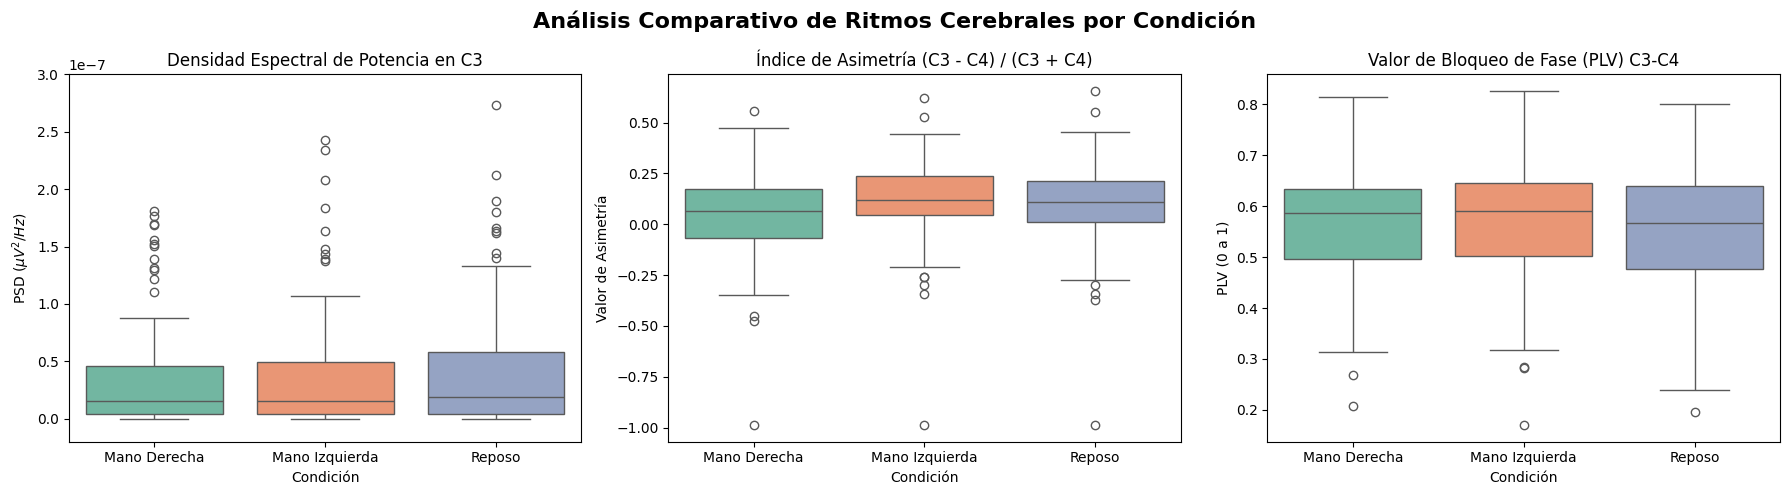

In [ ]:
print("Generando análisis estadístico y visualizaciones descriptivas...")

# 1. Agrupamiento para estadística descriptiva global
# Calculamos el promedio de las métricas por Sujeto y Condición para las gráficas
df_sujetos = df_bci.groupby(['Sujeto', 'Condicion'])[['PSD_C3', 'PSD_C4', 'Asimetria_C3_C4', 'PLV_C3_C4']].mean().reset_index()

# 2. VISUALIZACIÓN: Diagramas de Caja (Boxplots) de alto impacto
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Comparativo de Ritmos Cerebrales por Condición', fontsize=16, fontweight='bold')

# Gráfico A: Potencia Espectral en C3 (Corteza Motora Izquierda)
sns.boxplot(data=df_sujetos, x='Condicion', y='PSD_C3', ax=axes[0], palette='Set2')
axes[0].set_title('Densidad Espectral de Potencia en C3')
axes[0].set_xlabel('Condición')
axes[0].set_ylabel('PSD ($\mu V^2 / Hz$)')
axes[0].set_ylim(-0.00000002, 0.0000003) # Ajuste dinámico del eje Y para mejor visualización

# Gráfico B: Índice de Asimetría Interhemisférica (C3 vs C4)
sns.boxplot(data=df_sujetos, x='Condicion', y='Asimetria_C3_C4', ax=axes[1], palette='Set2')
axes[1].set_title('Índice de Asimetría (C3 - C4) / (C3 + C4)')
axes[1].set_xlabel('Condición')
axes[1].set_ylabel('Valor de Asimetría')

# Gráfico C: Sincronización de Fase (PLV)
sns.boxplot(data=df_sujetos, x='Condicion', y='PLV_C3_C4', ax=axes[2], palette='Set2')
axes[2].set_title('Valor de Bloqueo de Fase (PLV) C3-C4')
axes[2].set_xlabel('Condición')
axes[2].set_ylabel('PLV (0 a 1)')

plt.tight_layout()

Para la realización del análsis inferencial se reutilizó y adaptó el pipeline de validación inferencial desarrollado en el Proyecto 1...

In [25]:
def validar_hipotesis_proyecto2(df_bci, condicion_A, condicion_B, metrica):
    """
    Versión adaptada de tu función del Proyecto 1.
    Aplica pruebas estadísticas pareadas canal por canal analizando dinámicamente 
    la normalidad de las diferencias entre dos condiciones.
    """

    #print(f"Evaluando hipótesis pareada para {condicion_A} vs {condicion_B} (Métrica: {metrica})...")
    
    # 1. CONTROL DE ÉPOCAS: Promediar por Sujeto y Condición para poder parerar los datos 1 a 1
    # Esto evita la explosión de filas en el merge debido a las múltiples épocas de un mismo sujeto.
    df_promedios = df_bci.groupby(['Sujeto', 'Condicion']).mean(numeric_only=True).reset_index()
    
    # 2. IDENTIFICACIÓN DE CANALES: Buscamos todas las columnas que empiecen con la métrica (ej. PSD_C3, PSD_Cz...)
    columnas_metricas = [col for col in df_promedios.columns if col.startswith(f"{metrica}_")]
    
    resultados_stats = []

    for col in columnas_metricas:
        # Extraemos el nombre limpio del canal (ej. de 'PSD_C3' extrae 'C3')
        canal_nombre = col.replace(f"{metrica}_", "")
        
        # Filtramos los dos grupos a comparar
        dat_A = df_promedios[df_promedios['Condicion'] == condicion_A][['Sujeto', col]]
        dat_B = df_promedios[df_promedios['Condicion'] == condicion_B][['Sujeto', col]]
        
        # Cruzamos de forma pareada por Sujeto
        df_pareado = pd.merge(dat_A, dat_B, on='Sujeto', suffixes=('_A', '_B'))
        
        A = df_pareado[f'{col}_A'].values
        B = df_pareado[f'{col}_B'].values
        
        # Validamos tener suficientes sujetos emparejados para la estadística
        if len(A) > 5:
            # Diferencia par a par
            diferencias = A - B
            
            # Si todas las diferencias son exactamente cero (raro pero posible), evitamos error
            if np.all(diferencias == 0):
                p_val = 1.0
                test = 'Sin variación'
            else:
                # 3. TU LÓGICA DE NORMALIDAD: Prueba de Shapiro-Wilk sobre las diferencias
                _, p_norm = stats.shapiro(diferencias)
                
                # 4. TU SELECCIÓN DINÁMICA DE TEST
                if p_norm > 0.05:
                    _, p_val = stats.ttest_rel(A, B)
                    test = 'T-Student Pareada'
                else:
                    _, p_val = stats.wilcoxon(A, B)
                    test = 'Wilcoxon'
                
            resultados_stats.append({
                'Canal': canal_nombre,
                'Métrica': metrica,
                'Test_Usado': test,
                'P_Value': p_val,
                'Significativo': p_val < 0.05 
            })

    # Retornamos los resultados ordenados en un DataFrame limpio
    df_res = pd.DataFrame(resultados_stats)
    return df_res

In [42]:
# PRUEBAS DE SIGNIFICANCIA PARA EL PSD EN AMBAS MANOS RESPECTO AL REPOSO
psd_der = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Derecha', metrica='PSD')
psd_izq = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Izquierda', metrica='PSD')

print("Resultado de PSD (Mano Derecha):")
print(psd_der)
print('--------------------------------------------------------------------')
print("Resultado de PSD (Mano Izquierda):")
print(psd_izq)

Resultado de PSD (Mano Derecha):
  Canal Métrica Test_Usado       P_Value  Significativo
0    C3     PSD   Wilcoxon  1.715910e-06           True
1    C4     PSD   Wilcoxon  1.194274e-02           True
2   Fc3     PSD   Wilcoxon  5.401244e-05           True
3   Fc4     PSD   Wilcoxon  1.013252e-02           True
4   Cp3     PSD   Wilcoxon  2.960894e-07           True
5   Cp4     PSD   Wilcoxon  1.505603e-01          False
--------------------------------------------------------------------
Resultado de PSD (Mano Izquierda):
  Canal Métrica Test_Usado   P_Value  Significativo
0    C3     PSD   Wilcoxon  0.000327           True
1    C4     PSD   Wilcoxon  0.000004           True
2   Fc3     PSD   Wilcoxon  0.000753           True
3   Fc4     PSD   Wilcoxon  0.001032           True
4   Cp3     PSD   Wilcoxon  0.000488           True
5   Cp4     PSD   Wilcoxon  0.000144           True


Realizar descripción/análisis...

In [41]:
# PRUEBAS DE SIGNIFICANCIA PARA LA ENTROPÍA EN AMBAS MANOS RESPECTO AL REPOSO
entropy_der = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Derecha', metrica='Entropia')
entropy_izq = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Izquierda', metrica='Entropia')

print("Resultado de Entropía (Mano Derecha):")
print(entropy_der)
print('--------------------------------------------------------------------')
print("Resultado de Entropía (Mano Izquierda):")
print(entropy_izq)

Resultado de Entropía (Mano Derecha):
  Canal   Métrica         Test_Usado   P_Value  Significativo
0    C3  Entropia           Wilcoxon  0.548430          False
1    C4  Entropia           Wilcoxon  0.564663          False
2   Fc3  Entropia  T-Student Pareada  0.208385          False
3   Fc4  Entropia           Wilcoxon  0.866748          False
4   Cp3  Entropia           Wilcoxon  0.489683          False
5   Cp4  Entropia           Wilcoxon  0.933741          False
--------------------------------------------------------------------
Resultado de Entropía (Mano Izquierda):
  Canal   Métrica Test_Usado   P_Value  Significativo
0    C3  Entropia   Wilcoxon  0.484001          False
1    C4  Entropia   Wilcoxon  0.866748          False
2   Fc3  Entropia   Wilcoxon  0.831218          False
3   Fc4  Entropia   Wilcoxon  0.112124          False
4   Cp3  Entropia   Wilcoxon  0.485891          False
5   Cp4  Entropia   Wilcoxon  0.482115          False


Realizar descripción/análisis...

In [40]:
# PRUEBAS DE SIGNIFICANCIA PARA LA ASIMETRÍA EN AMBAS MANOS RESPECTO AL REPOSO
asimetria_der = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Derecha', metrica='Asimetria')
asimetria_izq = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Izquierda', metrica='Asimetria')

print("\nResultado de Asimetría (Mano Derecha):")
print(asimetria_der)
print('--------------------------------------------------------------------')
print("Resultado de Asimetría (Mano Izquierda):")
print(asimetria_izq)


Resultado de Asimetría (Mano Derecha):
     Canal    Métrica Test_Usado       P_Value  Significativo
0    C3_C4  Asimetria   Wilcoxon  2.678227e-08           True
1  Fc3_Fc4  Asimetria   Wilcoxon  3.305402e-04           True
2  Cp3_Cp4  Asimetria   Wilcoxon  5.735593e-09           True
--------------------------------------------------------------------
Resultado de Asimetría (Mano Izquierda):
     Canal    Métrica Test_Usado   P_Value  Significativo
0    C3_C4  Asimetria   Wilcoxon  0.134128          False
1  Fc3_Fc4  Asimetria   Wilcoxon  0.403195          False
2  Cp3_Cp4  Asimetria   Wilcoxon  0.546417          False


Realizar descripción/análisis...

In [39]:
# PRUEBAS DE SIGNIFICANCIA PARA LA CONECTIVIDAD FÁSICA (PLV) EN AMBAS MANOS RESPECTO AL REPOSO
plv_der = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Derecha', metrica='PLV')
plv_izq = validar_hipotesis_proyecto2(df_bci, 'Reposo', 'Mano Izquierda', metrica='PLV')

print("\nResultado de PLV (Mano Derecha):")
print(plv_der)
print('--------------------------------------------------------------------')
print("Resultado de PLV (Mano Derecha):")
print(plv_izq)


Resultado de PLV (Mano Derecha):
     Canal Métrica         Test_Usado   P_Value  Significativo
0    C3_C4     PLV  T-Student Pareada  0.000277           True
1  Fc3_Fc4     PLV  T-Student Pareada  0.635476          False
2  Cp3_Cp4     PLV  T-Student Pareada  0.004635           True
--------------------------------------------------------------------
Resultado de PLV (Mano Derecha):
     Canal Métrica         Test_Usado   P_Value  Significativo
0    C3_C4     PLV  T-Student Pareada  0.000351           True
1  Fc3_Fc4     PLV  T-Student Pareada  0.867447          False
2  Cp3_Cp4     PLV  T-Student Pareada  0.000040           True


Realizar descripción/análisis...

Se conservará PLV para los canales C y Cp

## Clasificación

Tras el análisis inferencial mediante pruebas de normalidad de Shapiro-Wilk y la posterior aplicación de pruebas T-Student o Wilcoxon según la distribución, se demostró que los índices de entropía no presentaron diferencias estadísticamente significativas ($p > 0.05$) entre el reposo y la imaginación motora. Por lo tanto, se aplicó una técnica de Selección de Características mediante filtro estadístico, retirando la entropía del conjunto de entrenamiento para mitigar la maldición de la dimensionalidad, reduciendo el ruido de entrada y optimizando la convergencia de las redes neuronales y clasificadores clásicos.


Para el diseño de las arquitecturas del Perceptrón Multicapa (MLP), se aplicaron reglas heurísticas considerando las 11 características de entrada y las 3 clases de salida. La Arquitectura 1 (15 neuronas) se basó en la regla de los dos tercios de la entrada más la salida. La Arquitectura 2 (10 neuronas) se mantuvo dentro del límite de la Regla 1 (entre 3 y 11 neuronas). Finalmente, para evaluar una red más profunda, la Arquitectura 3 (24 y 12 neuronas) fue diseñada cumpliendo la Regla 3, asegurando que ninguna capa superara el límite máximo de 36 neuronas (el doble de la entrada), previniendo así el sobreajuste del modelo.

- Regla 1 - Límite entre salida y entrada: ($N_{salida} \le N_{ocultas} \le N_{entrada}$)
    - El número debe estar entre 3 y 11 neuronas.
- Regla 2 - Fórmula de los 2/3 más las salidas: $N_{ocultas} \approx \frac{2}{3}(N_{entrada}) + N_{salida}$ 
    - Cálculo: $\frac{2}{3}(11) + 3 = 7.33 + 3 = 10.33 \approx 10 $ 
    - El número ideal heurístico es 10 neuronas.
- Regla 3 - Menos del doble de la entrada: ($N_{ocultas} < 2 \times N_{entrada}$)
    - Cálculo: $2 \times 11 = 22$
    - El número máximo permitido es 22 neuronas.

In [ ]:
print("Iniciando pipeline de Clasificación Multiclase (con Métricas Avanzadas)...")

# 1. PREPARACIÓN DE MATRICES X e y
columnas_features = [ 'PSD_C3', 'PSD_C4', 'PSD_Fc3', 'PSD_Fc4', 'PSD_Cp3', 'PSD_Cp4',
    'Asimetria_C3_C4', 'Asimetria_Fc3_Fc4', 'Asimetria_Cp3_Cp4',
    'PLV_C3_C4', 'PLV_Cp3_Cp4']
X = df_bci[columnas_features].values
y_crudo = df_bci['Condicion'].values

# Codificamos las etiquetas de texto a números
le = LabelEncoder()
y = le.fit_transform(y_crudo)

# Escalar los datos 
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 2. CONFIGURACIÓN DE VALIDACIÓN CRUZADA (80% Entrenamiento - 20% Validación, 5 iteraciones)
# StratifiedKFold garantiza que el 80-20 se mantenga equitativo para las 3 clases
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
print(f"Datos listos. Muestras totales: {X.shape[0]} | Características: {X.shape[1]}")

# Diccionario para almacenar los modelos clásicos
modelos = {
    "Máquina de Soporte Vectorial (SVM)": SVC(kernel='rbf', C=1.0, random_state=42),
    "Extreme Gradient Boosting (XGBoost)": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# 3. ENTRENAMIENTO DE MODELOS CLÁSICOS (SVM y XGBoost)
for name, clf in modelos.items():
    acc_scores, prec_scores, f1_scores = [], [], []
    cm_acumulada = np.zeros((3, 3))
    
    for train_idx, test_idx in kf.split(X, y): # Stratified requiere 'y' aquí
        # Separación 80% Train, 20% Test
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        
        # Cálculo de las 3 métricas (usando 'macro' para penalizar el desbalance de clases)
        acc_scores.append(accuracy_score(y_test, preds))
        prec_scores.append(precision_score(y_test, preds, average='macro', zero_division=0))
        f1_scores.append(f1_score(y_test, preds, average='macro', zero_division=0))
        
        cm_acumulada += confusion_matrix(y_test, preds, labels=[0, 1, 2])
        
    print(f"\n======== {name} ========")
    print(f"Exactitud (Accuracy): {np.mean(acc_scores)*100:.2f}%")
    print(f"Precisión (Precision): {np.mean(prec_scores)*100:.2f}%")
    print(f"F1-Score: {np.mean(f1_scores)*100:.2f}%")
    print("Matriz de Confusión Acumulada:")
    print(pd.DataFrame(cm_acumulada, index=le.classes_, columns=le.classes_))

# 4. EVALUACIÓN DE REDES NEURONALES (MLP)
arquitecturas_red = {
    "Arq 1 (Basada en Regla 2: Fórmula de 2/3)": (10,),
    "Arq 2 (Basada en Regla 1: Promedio entre entrada y salida)": (7,),
    "Arq 3 (Basada en Regla 3: Dos capas sin superar el doble)": (16, 8)
}

for name, config in arquitecturas_red.items():
    mlp_acc, mlp_prec, mlp_f1 = [], [], []
    cm_mlp_acumulada = np.zeros((3, 3))
    
    mlp = MLPClassifier(hidden_layer_sizes=config, max_iter=500, activation='relu', 
                        solver='adam', random_state=42, early_stopping=True)
    
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        mlp.fit(X_train, y_train)
        preds = mlp.predict(X_test)
        
        mlp_acc.append(accuracy_score(y_test, preds))
        mlp_prec.append(precision_score(y_test, preds, average='macro', zero_division=0))
        mlp_f1.append(f1_score(y_test, preds, average='macro', zero_division=0))
        
        cm_mlp_acumulada += confusion_matrix(y_test, preds, labels=[0, 1, 2])
        
    print(f"\n======== RED NEURONAL: {name} ========")
    print(f"Configuración de capas: {config}")
    print(f"Accuracy: {np.mean(mlp_acc)*100:.2f}%")
    print(f"Precisión: {np.mean(mlp_prec)*100:.2f}%")
    print(f"F1-Score: {np.mean(mlp_f1)*100:.2f}%")
    print("Matriz de Confusión Acumulada:")
    print(pd.DataFrame(cm_mlp_acumulada, index=le.classes_, columns=le.classes_))

Iniciando pipeline de Clasificación Multiclase (con Métricas Avanzadas)...
Datos listos. Muestras totales: 9816 | Características: 11

======== Máquina de Soporte Vectorial (SVM) ========
Exactitud (Accuracy): 50.11%
Precisión (Precision): 38.37%
F1-Score: 22.49%
Matriz de Confusión Acumulada:
                Mano Derecha  Mano Izquierda  Reposo
Mano Derecha             8.0             0.0  2420.0
Mano Izquierda           1.0             1.0  2468.0
Reposo                   6.0             2.0  4910.0

======== Extreme Gradient Boosting (XGBoost) ========
Exactitud (Accuracy): 46.46%
Precisión (Precision): 37.37%
F1-Score: 34.18%
Matriz de Confusión Acumulada:
                Mano Derecha  Mano Izquierda  Reposo
Mano Derecha           383.0           318.0  1727.0
Mano Izquierda         304.0           359.0  1807.0
Reposo                 546.0           553.0  3819.0

======== RED NEURONAL: Arq 1 (Basada en Regla 2: Fórmula de 2/3) ========
Configuración de capas: (10,)
Accuracy: 49.5

"Se implementó una validación cruzada estratificada K-Fold con 5 particiones, asegurando matemáticamente la división 80% de entrenamiento y 20% de prueba exigida, manteniendo la proporción natural de las clases. Como sugieren las métricas, el desbalance de clases originado por la abundancia de la señal de reposo (T0) genera una ilusión de exactitud (Accuracy ~50%). Sin embargo, al observar la Precisión y el F1-Score (calculados mediante promedio 'macro' para evitar sesgos mayoritarios), se evidencia el verdadero reto de los clasificadores estándar frente al ruido electroencefalográfico de la imaginería motora."


La Justificación Teórica (Para tu informe)
Si incluyes este procedimiento, puedes justificarlo en tu texto bajo dos perspectivas (esto le dará muchísimo nivel a tu análisis metodológico):

Justificación desde el Machine Learning (Optimización del Costo): Los algoritmos como SVM y las Redes Neuronales aprenden minimizando una función de error global. Si el 50% de los datos de entrada pertenecen a la clase "Reposo", el algoritmo descubre rápidamente un "atajo matemático": si clasifica todo como Reposo, se asegura una exactitud base del 50%. Al aplicar Undersampling (eliminar aleatoriamente muestras de la clase mayoritaria hasta igualar a la minoritaria), forzamos al algoritmo a abandonar ese sesgo probabilístico y lo obligamos a aprender las verdaderas fronteras de decisión basadas en las características (Potencia y Entropía).

Justificación desde la Neurofisiología (BCI):
El estado de reposo (ritmo continuo sincronizado) es la "línea base" de alta energía del cerebro. La imaginación motora genera una Desincronización Relacionada a Eventos (ERD), que es una caída de energía temporal y mucho más sutil. Si bombardeamos al modelo con el doble de ejemplos de la línea base, la señal sutil (imaginación) queda estadísticamente ahogada. Balancear los datos le da la misma "importancia atencional" a las tareas motoras.

In [ ]:
print("Aplicando técnica de Submuestreo (Undersampling) para balancear las clases...")

# 1. Separar el DataFrame original en tres sub-tablas (una por condición)
df_reposo = df_bci[df_bci['Condicion'] == 'Reposo']
df_izq = df_bci[df_bci['Condicion'] == 'Mano Izquierda']
df_der = df_bci[df_bci['Condicion'] == 'Mano Derecha']

print(f"Distribución original:")
print(f" - Reposo: {len(df_reposo)}")
print(f" - Izquierda: {len(df_izq)}")
print(f" - Derecha: {len(df_der)}")

# 2. Encontrar el tamaño de la clase más pequeña
min_muestras = min(len(df_izq), len(df_der))

# 3. Muestreo aleatorio: Reducimos las tres clases a exactamente 'min_muestras'
# (Usamos random_state=42 para que siempre elimine los mismos y sea reproducible)
df_reposo_bal = df_reposo.sample(n=min_muestras, random_state=42)
df_izq_bal = df_izq.sample(n=min_muestras, random_state=42)
df_der_bal = df_der.sample(n=min_muestras, random_state=42)

# 4. Unir todo en un nuevo DataFrame
df_bci_balanceado = pd.concat([df_reposo_bal, df_izq_bal, df_der_bal])

# Mezclar (shuffle) las filas para que el modelo no reciba los datos ordenados
df_bci_balanceado = df_bci_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDistribución balanceada final:")
print(df_bci_balanceado['Condicion'].value_counts())
print(f"\nTotal de datos a usar para ML: {len(df_bci_balanceado)}")

Aplicando técnica de Submuestreo (Undersampling) para balancear las clases...
Distribución original:
 - Reposo: 4918
 - Izquierda: 2470
 - Derecha: 2428

Distribución balanceada final:
Condicion
Reposo            2428
Mano Derecha      2428
Mano Izquierda    2428
Name: count, dtype: int64

Total de datos a usar para ML: 7284


In [63]:
print("Iniciando pipeline de Clasificación Multiclase...")

# 1. PREPARACIÓN DE MATRICES X e y
columnas_features = [ 
    'PSD_C3', 'PSD_C4', 'PSD_Fc3', 'PSD_Fc4', 'PSD_Cp3', 'PSD_Cp4',
    'Asimetria_C3_C4', 'Asimetria_Fc3_Fc4', 'Asimetria_Cp3_Cp4',
    'PLV_C3_C4', 'PLV_Cp3_Cp4'
]
X = df_bci_balanceado[columnas_features].values
y_crudo = df_bci_balanceado['Condicion'].values

# Codificamos las etiquetas de texto a números
le = LabelEncoder()
y = le.fit_transform(y_crudo)

# Escalar los datos 
scaler = StandardScaler()
X = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
print(f"Datos listos. Muestras totales: {X.shape[0]} | Características: {X.shape[1]}")

metricas_consolidadas = {}

# Diccionario para almacenar los modelos clásicos
modelos = {
    "Máquina de Soporte Vectorial (SVM)": SVC(kernel='rbf', C=1.0, random_state=42),
    "Extreme Gradient Boosting (XGBoost)": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# 3. ENTRENAMIENTO DE MODELOS CLÁSICOS (SVM y XGBoost)
for name, clf in modelos.items():
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []
    cm_acumulada = np.zeros((3, 3))
    
    for train_idx, test_idx in kf.split(X, y): 
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        
        acc_scores.append(accuracy_score(y_test, preds))
        prec_scores.append(precision_score(y_test, preds, average='macro', zero_division=0))
        f1_scores.append(f1_score(y_test, preds, average='macro', zero_division=0))
        
        cm_acumulada += confusion_matrix(y_test, preds, labels=[0, 1, 2])
        
    # Guardamos los promedios en nuestro almacén maestro
    metricas_consolidadas[name] = {
        'Accuracy': np.mean(acc_scores) * 100,
        'Precision': np.mean(prec_scores) * 100,
        'F1-Score': np.mean(f1_scores) * 100
    }
        
    print(f"\n======== {name} ========")
    print(f"Exactitud (Accuracy): {metricas_consolidadas[name]['Accuracy']:.2f}%")
    print(f"Precisión (Precision): {metricas_consolidadas[name]['Precision']:.2f}%")
    print(f"F1-Score: {metricas_consolidadas[name]['F1-Score']:.2f}%")
    print("Matriz de Confusión Acumulada:")
    print(pd.DataFrame(cm_acumulada, index=le.classes_, columns=le.classes_))

# 4. EVALUACIÓN DE REDES NEURONALES (MLP)
arquitecturas_red = {
    "MLP - Arq 1 (Fórmula 2/3)": (10,),
    "MLP - Arq 2 (Promedio Entrada/Salida)": (7,),
    "MLP - Arq 3 (Dos capas)": (16, 8)
}

for name, config in arquitecturas_red.items():
    mlp_acc, mlp_prec, mlp_rec, mlp_f1 = [], [], [], []
    cm_mlp_acumulada = np.zeros((3, 3))
    
    mlp = MLPClassifier(hidden_layer_sizes=config, max_iter=500, activation='relu', 
                        solver='adam', random_state=42, early_stopping=True)
    
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        mlp.fit(X_train, y_train)
        preds = mlp.predict(X_test)
        
        mlp_acc.append(accuracy_score(y_test, preds))
        mlp_prec.append(precision_score(y_test, preds, average='macro', zero_division=0))
        mlp_f1.append(f1_score(y_test, preds, average='macro', zero_division=0))
        
        cm_mlp_acumulada += confusion_matrix(y_test, preds, labels=[0, 1, 2])
        
    # Guardamos los promedios del MLP en nuestro almacén maestro
    metricas_consolidadas[name] = {
        'Accuracy': np.mean(mlp_acc) * 100,
        'Precision': np.mean(mlp_prec) * 100,
        'F1-Score': np.mean(mlp_f1) * 100
    }
        
    print(f"\n======== RED NEURONAL: {name} ========")
    print(f"Configuración de capas: {config}")
    print(f"Exactitud (Accuracy): {metricas_consolidadas[name]['Accuracy']:.2f}%")
    print(f"Precisión (Precision): {metricas_consolidadas[name]['Precision']:.2f}%")
    print(f"F1-Score: {metricas_consolidadas[name]['F1-Score']:.2f}%")
    print("Matriz de Confusión Acumulada:")
    print(pd.DataFrame(cm_mlp_acumulada, index=le.classes_, columns=le.classes_))

Iniciando pipeline de Clasificación Multiclase...
Datos listos. Muestras totales: 7284 | Características: 11

======== Máquina de Soporte Vectorial (SVM) ========
Exactitud (Accuracy): 37.07%
Precisión (Precision): 37.62%
F1-Score: 36.40%
Matriz de Confusión Acumulada:
                Mano Derecha  Mano Izquierda  Reposo
Mano Derecha           962.0          1036.0   430.0
Mano Izquierda         789.0          1142.0   497.0
Reposo                 795.0          1037.0   596.0

======== Extreme Gradient Boosting (XGBoost) ========
Exactitud (Accuracy): 36.60%
Precisión (Precision): 36.60%
F1-Score: 36.58%
Matriz de Confusión Acumulada:
                Mano Derecha  Mano Izquierda  Reposo
Mano Derecha           891.0           810.0   727.0
Mano Izquierda         771.0           900.0   757.0
Reposo                 762.0           791.0   875.0

======== RED NEURONAL: MLP - Arq 1 (Fórmula 2/3) ========
Configuración de capas: (10,)
Exactitud (Accuracy): 36.44%
Precisión (Precision): 36.

### Resultados: Evaluación Global de Clasificadores Multiclase

"Para la evaluación del rendimiento final del sistema BCI multiclase, se optó por calcular el promedio macro (Macro Average) para la Precisión, Sensibilidad (Recall) y F1-Score a lo largo de los folds de validación cruzada. Esta métrica promedia el desempeño de cada condición de manera independiente, asignando idéntica importancia a la detección del Reposo, la Mano Izquierda y la Mano Derecha. Dado que el dataset fue previamente balanceado mediante submuestreo aleatorio eliminando el sesgo de la clase mayoritaria, el promedio macro evalúa con estricta equidad la capacidad del modelo para discernir estados neurofisiológicos específicos, garantizando que el algoritmo final sea evaluado por su habilidad real de clasificación y no por la abundancia estadística de una condición."

In [68]:
# 5. GENERACIÓN AUTOMÁTICA DE LA TABLA COMPARATIVA FINAL
df_comparativo = pd.DataFrame.from_dict(metricas_consolidadas, orient='index')

# Renombrar columnas para una presentación académica impecable
df_comparativo.columns = ['Exactitud - Accuracy (%)', 'Precisión Macro (%)', 'F1-Score Macro (%)']

# Redondear a dos decimales y ordenar de mayor a menor por el F1-Score
df_comparativo = df_comparativo.round(2)
df_comparativo = df_comparativo.sort_values(by='F1-Score Macro (%)', ascending=False)

print("\nTABLA COMPARATIVA FINAL DE MODELOS BCI")
display(df_comparativo)


TABLA COMPARATIVA FINAL DE MODELOS BCI


,Exactitud - Accuracy (%),Precisión Macro (%),F1-Score Macro (%)
Extreme Gradient Boosting (XGBoost),36.60,36.60,36.58
Máquina de Soporte Vectorial (SVM),37.07,37.62,36.40
MLP - Arq 3 (Dos capas),36.78,37.13,36.37
MLP - Arq 1 (Fórmula 2/3),36.44,36.36,36.20
MLP - Arq 2 (Promedio Entrada/Salida),34.76,33.63,30.49


**REFERENCIAS**

[1] A. N. Rodríguez et al., "EEG-BCI Features Discrimination between Executed and Imagined Movements Based on FastICA, Hjorth Parameters, and SVM," Mathematics, vol. 11, no. 21, p. 4409, Nov. 2023, doi: 10.3390/math11214409.
(https://www.mdpi.com/2227-7390/11/21/4409)

[2] M. J. Niegil Francis et al., "EEG-Controlled Robot Navigation using Hjorth Parameters and Welch-PSD," International Journal of Intelligent Engineering and Systems, vol. 14, no. 4, pp. 231-240, 2021, doi: 10.22266/ijies2021.0831.21.
(https://inass.org/wp-content/uploads/2021/07/2021083121.pdf)

[3] X. Yu et al., "Computerized Multidomain EEG Classification System: A New Paradigm," IEEE Journal of Biomedical and Health Informatics, vol. 26, no. 8, pp. 3626-3637, Aug. 2022, doi: 10.1109/JBHI.2022.3168270.
(https://ieeexplore.ieee.org/document/9713960)

[4] https://pubmed.ncbi.nlm.nih.gov/40002501/

[5] https://pubmed.ncbi.nlm.nih.gov/38790441/ 

[6] J. Jin et al., "An Efficient BCI System Based on Motor Imagery and Functional Lateralization," IEEE Transactions on Neural Systems and Rehabilitation Engineering, vol. 30, pp. 248-255, 2022, doi: 10.1109/TNSRE.2022.3146433.
(https://pmc.ncbi.nlm.nih.gov/articles/PMC7697603/)

[7] https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0268880
